In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from src.data_loader import DataLoader
from src.statistics import StatisticalAnalyzer
from src.visualizations import (
    plot_histogram_with_distribution,
    create_correlation_heatmap,
    plot_boxplots_by_category,
    create_interactive_scatter,
    plot_qq_comparison,
    dashboard_layout,
)

loader = DataLoader(data_dir="../data")
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,culmen_area_mm2,flipper_to_mass_ratio
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,MALE,731.170,0.048267
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,FEMALE,687.300,0.048947
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,FEMALE,725.400,0.060000
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,MALE,768.985,0.048642
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,FEMALE,708.310,0.055942


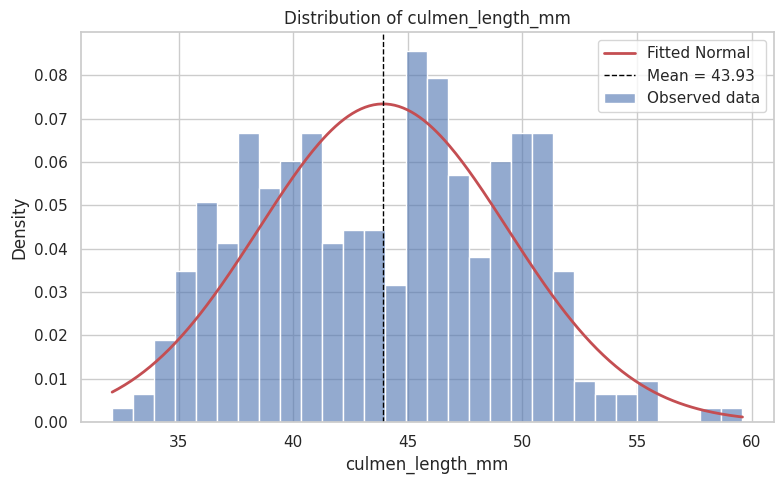

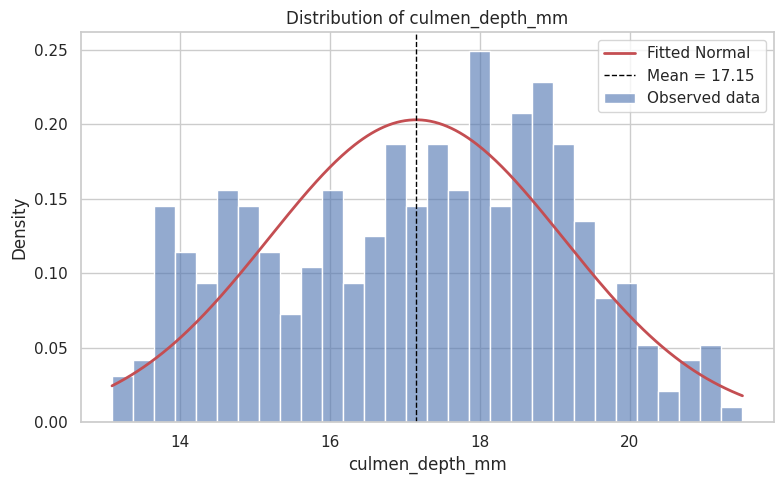

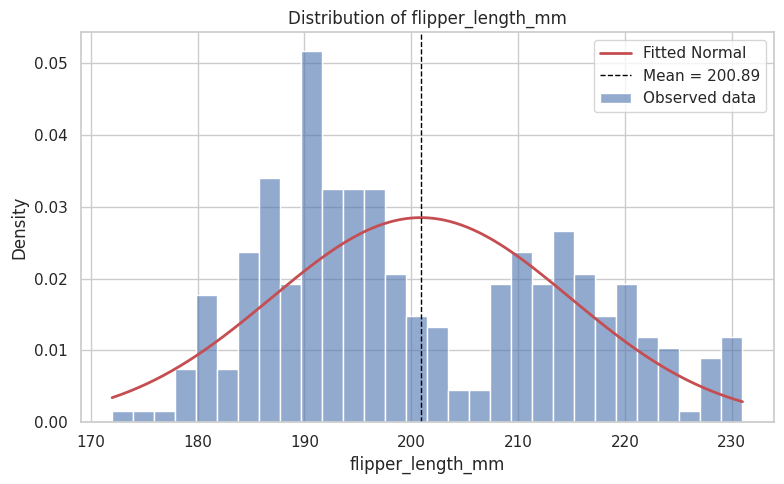

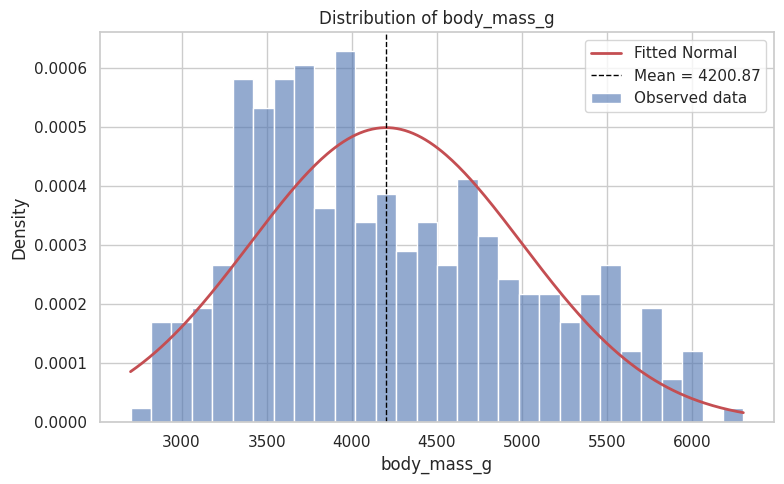

In [2]:
import os
os.makedirs('../reports/figures', exist_ok=True)

numeric_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

for col in numeric_cols:
    fig = plot_histogram_with_distribution(df[col], 'normal', col)
    fig.savefig(f'../reports/figures/hist_{col}.png', dpi=150, bbox_inches='tight')


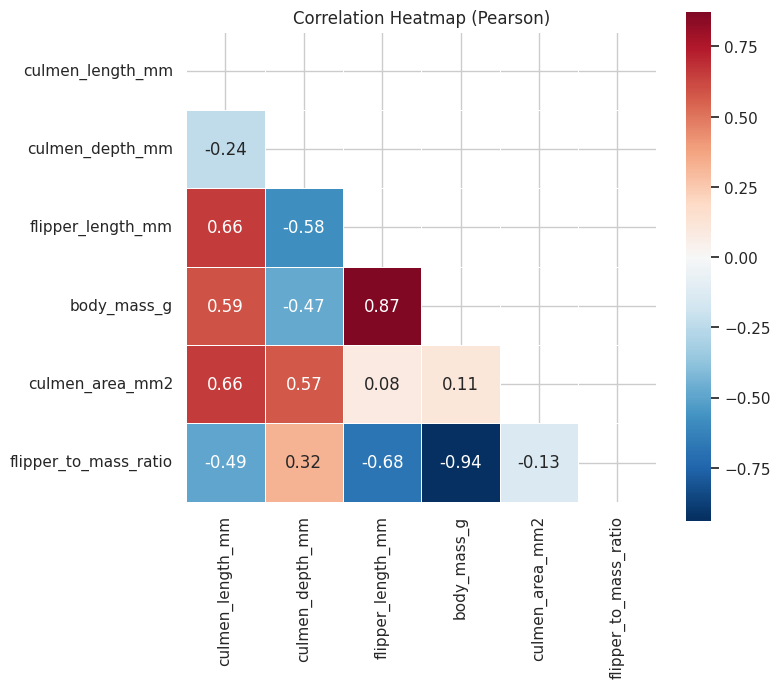

In [3]:
fig = create_correlation_heatmap(df)
fig.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')


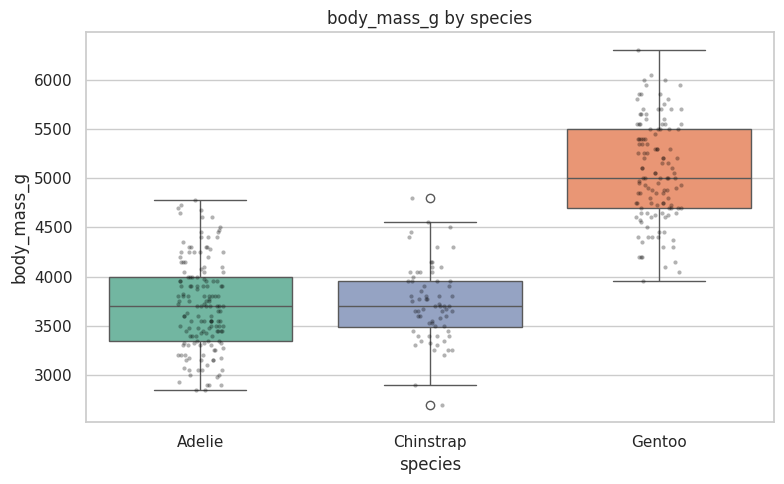

In [4]:
fig = plot_boxplots_by_category(df, 'body_mass_g', 'species')
fig.savefig('../reports/figures/boxplot_body_mass_by_species.png', dpi=150, bbox_inches='tight')


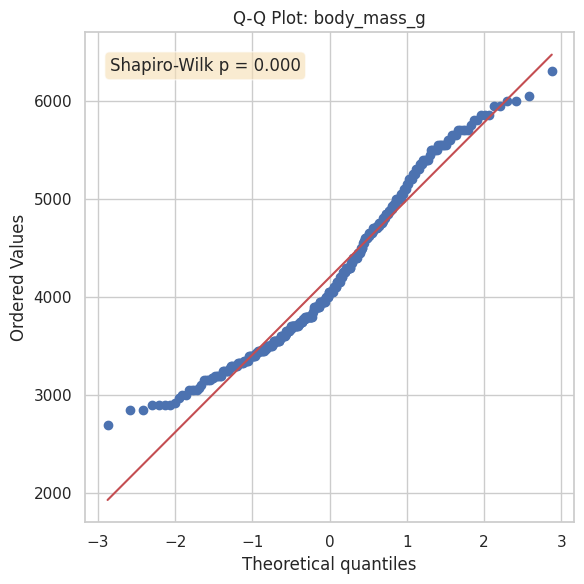

In [5]:
fig = plot_qq_comparison(df['body_mass_g'], 'norm', 'body_mass_g')
fig.savefig('../reports/figures/qq_body_mass.png', dpi=150, bbox_inches='tight')


In [6]:
scatter_fig = create_interactive_scatter(df, 'culmen_length_mm', 'culmen_depth_mm', 'species')
scatter_fig.write_html('../reports/figures/interactive_scatter.html')
scatter_fig.show()

In [7]:
dashboard_layout()

{'page_title': 'Statistics Superstars',
 'page_icon': '📊',
 'layout': 'wide',
 'analysis_types': ['Overview',
  'Distributions',
  'Hypothesis Testing',
  'Correlations']}